# Master Thesis Metrics Analysis - *100% AI Generated*

A narrative analysis of how thesis structure and writing style vary across departments and publication years.

## 1) Executive Summary

This notebook analyzes `master_thesis_metrics_analysis.csv` to uncover cross-department differences in thesis size and structure.

Primary questions:
- How much of each thesis is core content versus non-core pages (appendix/references)?
- How has thesis length changed over time?
- Which departments are more verbose in body text and abstract style?
- Which metrics move together and which appear independent?

In [11]:
# Core imports and display setup
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="talk")

In [12]:
# Locate project root and inspect baseline analysis artifacts
def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / "README.md").exists():
            return candidate
    return start

project_root = locate_project_root(Path.cwd())
print(f"Project root: {project_root}")

artifact_patterns = ["**/*.ipynb", "**/*.py", "**/*.png", "**/*.jpg", "**/*.jpeg", "**/*.svg"]
artifact_paths = []
for pattern in artifact_patterns:
    artifact_paths.extend(project_root.glob(pattern))

artifact_df = pd.DataFrame({"path": [str(p.relative_to(project_root)) for p in artifact_paths]}).drop_duplicates()
exclude_prefixes = (".venv/", "venv/", "__pycache__/", ".git/")
artifact_df = artifact_df[~artifact_df["path"].str.startswith(exclude_prefixes)]
artifact_df = artifact_df.assign(ext=artifact_df["path"].str.rsplit(".", n=1).str[-1].str.lower())

baseline_focus = artifact_df[artifact_df["path"].str.contains("exploring_data|exstraction_more_from_pdf|metrics", case=False, regex=True)]
print("Baseline analysis artifacts (sample):")
display(baseline_focus.sort_values("path").head(20))

print("Artifact counts by extension (excluding environment/cache files):")
display(artifact_df["ext"].value_counts().rename_axis("extension").to_frame("count"))

Project root: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR
Baseline analysis artifacts (sample):


,path,ext
1,exploring_data/Cleaning_Orbit_Meta.ipynb,ipynb
0,exploring_data/SANDBOX_Exploring_track1.ipynb,ipynb
5,exstraction_more_from_pdf/gcp_metrics_from_pdf...,py
6,exstraction_more_from_pdf/local_metrics_from_p...,py
3,exstraction_more_from_pdf/master_thesis_metric...,ipynb
2,exstraction_more_from_pdf/metrics_from_pdfs.ipynb,ipynb


Artifact counts by extension (excluding environment/cache files):


,count
extension,
py,12
ipynb,4


### Baseline to Advanced Evolution

The existing workspace already includes extraction notebooks and processing scripts. This notebook intentionally moves beyond basic summaries by adding:
- Robust join validation checks on thesis identifiers.
- Distribution-aware visuals (box/violin-style comparisons).
- Temporal median trends by department instead of single global averages.
- Correlation structure and anomaly inspection for deeper interpretation.

In [13]:
# Load data from the requested source name with robust fallbacks
candidate_paths = [
    project_root / "master_thesis_metrics_analysis.csv",
    project_root / "Data/gcp_order/dtu_findit/extraction_and_processing/master_thesis_metrics_analysis.csv",
    project_root / "Data/master_thesis_metrics_analysis.csv",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    discovered = list(project_root.glob("**/master_thesis_metrics_analysis.csv"))
    if not discovered:
        raise FileNotFoundError("Could not find master_thesis_metrics_analysis.csv in the project.")
    data_path = discovered[0]

df = pd.read_csv(data_path, sep=";", encoding="utf-8")
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")
display(df.head())

Loaded: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR/Data/gcp_order/dtu_findit/extraction_and_processing/master_thesis_metrics_analysis.csv
Shape: (2671, 13)


,pdf_file,member_id_ss_metrics,num_tot_pages,num_cont_pages,match_trigger,num_words_full,num_words_cont,abstract_ts,Author,Publication Year,primary_member_id_s,Title,Department_new
0,5ce67fe9d9001d016b4fccc7_Experimental analysis...,5ce67fe9d9001d016b4fccc7,66,62,exact ('references'),15415,13882,Department of Chemical and Biochemical Enginee...,"Joshi, Ameya Sunil",2019,5ce67fe9d9001d016b4fccc7,Experimental analysis of CO2 vapour liquid equ...,DTU Chemical Engineering
1,5c7a72ffd9001d361b4cd3ec_Heart segmentation us...,5c7a72ffd9001d361b4cd3ec,84,74,"prefix-match ('appendix a', prefix='appendix')",19892,18374,"In the ﬁeld of medical imaging, a lot of resea...","Ellegaard, Andreas Høyby",2019,5c7a72ffd9001d361b4cd3ec,Heart segmentation using deep learning|Segment...,DTU Compute
2,5cee68eed9001d2064299318_Deep Reinforcement Le...,5cee68eed9001d2064299318,61,51,exact ('references'),20540,17924,Robotic exploration in an unknown environment ...,"Hamilton, Francis Nils",2019,5cee68eed9001d2064299318,Deep Reinforcement Learning: Applying an actor...,DTU Electro
3,5cf10bded9001d206429933f_Data augmentation of ...,5cf10bded9001d206429933f,74,72,exact ('bibliography'),10694,10338,This thesis is about a deep learning segmentat...,"Talleruphuus, Anne Sofie",2019,5cf10bded9001d206429933f,Data augmentation of CT scans|Data augmentatio...,DTU Compute
4,5ce7d169d9001d016b01c693_Simulation and measur...,5ce7d169d9001d016b01c693,68,61,exact ('references'),16574,15988,Recent developments in North Atlantic Salmon a...,"Gaardlykke, Uni Sofus",2019,5ce7d169d9001d016b01c693,Simulation and measurement of three dimensiona...,DTU Construct


In [14]:
# 2) Data cleaning and join logic checks
required_cols = [
    "member_id_ss_metrics", "primary_member_id_s", "Department_new", "Publication Year",
    "num_tot_pages", "num_cont_pages", "num_words_cont", "num_words_full", "abstract_ts"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing expected columns: {missing_cols}")

for col in ["num_tot_pages", "num_cont_pages", "num_words_cont", "num_words_full"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Publication Year"] = pd.to_numeric(df["Publication Year"], errors="coerce")
df["Publication Year"] = df["Publication Year"].round().astype("Int64")
df["Department_new"] = df["Department_new"].astype("string").str.strip()

df["id_match"] = df["member_id_ss_metrics"].astype("string") == df["primary_member_id_s"].astype("string")
df["abstract_word_count"] = df["abstract_ts"].astype("string").str.split().str.len()

quality_summary = pd.DataFrame({
    "metric": [
        "rows_total",
        "id_mismatch_rows",
        "missing_department_rows",
        "missing_publication_year_rows",
        "rows_with_nonpositive_total_pages",
    ],
    "value": [
        len(df),
        (~df["id_match"]).sum(),
        df["Department_new"].isna().sum() + (df["Department_new"] == "").sum(),
        df["Publication Year"].isna().sum(),
        (df["num_tot_pages"] <= 0).sum(),
    ],
})
display(quality_summary)

analysis_df = df.copy()
analysis_df = analysis_df[analysis_df["id_match"]]
analysis_df = analysis_df.dropna(subset=["Department_new", "Publication Year", "num_tot_pages", "num_cont_pages", "num_words_cont"])
analysis_df = analysis_df[analysis_df["num_tot_pages"] > 0].copy()

analysis_df["content_ratio"] = (analysis_df["num_cont_pages"] / analysis_df["num_tot_pages"]).clip(lower=0, upper=1)
analysis_df["filler_share"] = (1 - analysis_df["content_ratio"]).clip(lower=0, upper=1)

print(f"Analysis-ready rows: {len(analysis_df):,}")

,metric,value
0,rows_total,2671
1,id_mismatch_rows,0
2,missing_department_rows,0
3,missing_publication_year_rows,0
4,rows_with_nonpositive_total_pages,0


Analysis-ready rows: 2,671


### Cleaning Insight

Join consistency is explicitly validated via `member_id_ss_metrics == primary_member_id_s`. Rows with missing department/year or invalid total page count are excluded from analytical modules to avoid biased department and temporal comparisons.

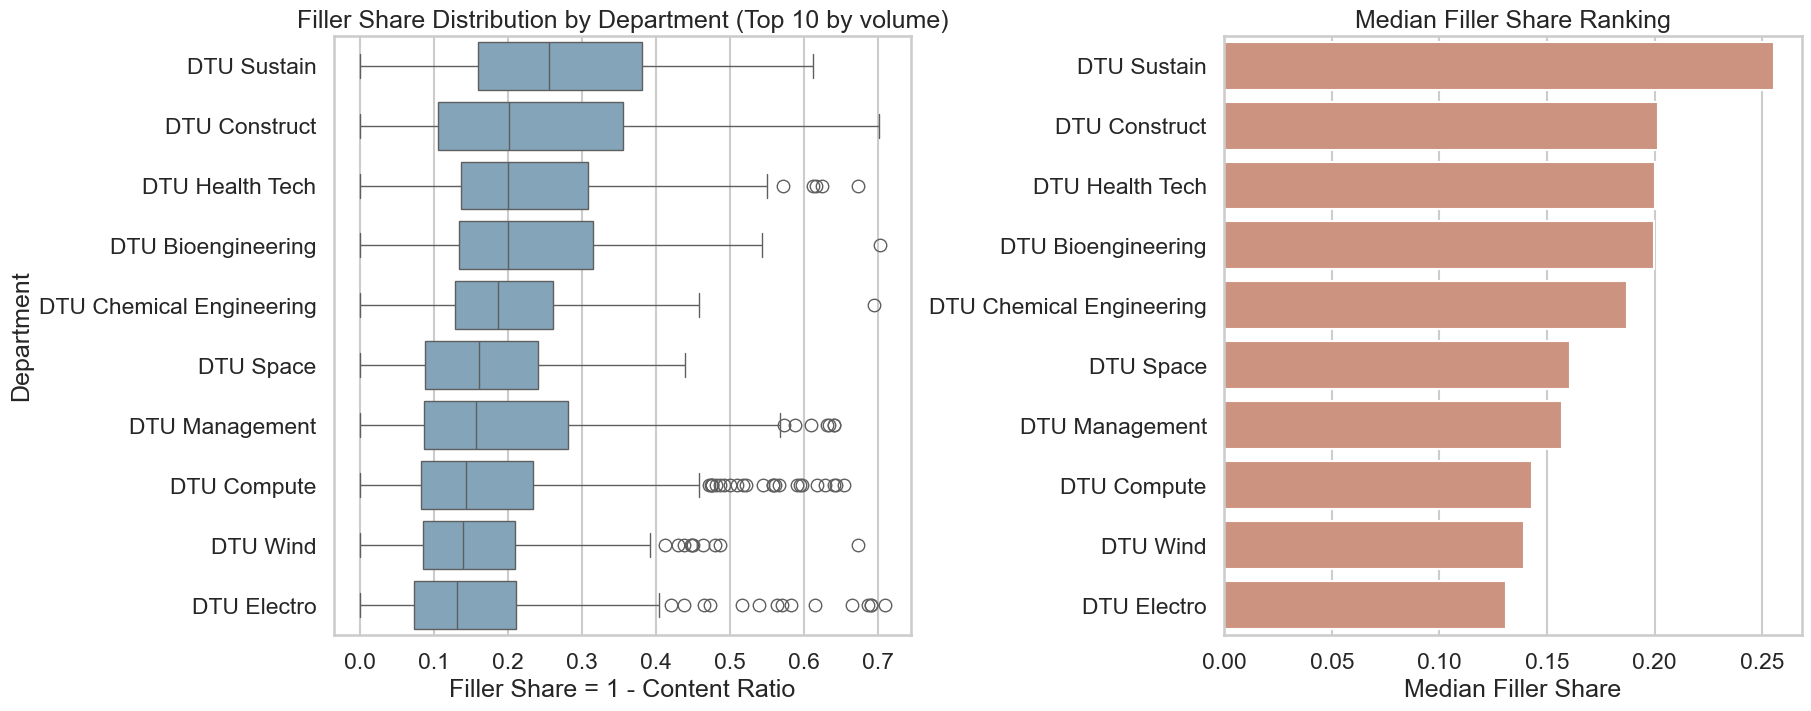

,Department_new,filler_share
8,DTU Sustain,0.255556
3,DTU Construct,0.201802
5,DTU Health Tech,0.200000
0,DTU Bioengineering,0.199549
1,DTU Chemical Engineering,0.186955
7,DTU Space,0.160494
6,DTU Management,0.156863
2,DTU Compute,0.142857
9,DTU Wind,0.139241
4,DTU Electro,0.131148


In [16]:
# 3A) The Content Ratio: core content vs non-core pages
dept_counts = analysis_df["Department_new"].value_counts()
top_departments = dept_counts.head(10).index
ratio_df = analysis_df[analysis_df["Department_new"].isin(top_departments)].copy()

dept_filler = (
    ratio_df.groupby("Department_new", as_index=False)["filler_share"]
    .median()
    .sort_values("filler_share", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
sns.boxplot(data=ratio_df, x="filler_share", y="Department_new", order=dept_filler["Department_new"], ax=axes[0], color="#7aa6c2")
axes[0].set_title("Filler Share Distribution by Department (Top 10 by volume)")
axes[0].set_xlabel("Filler Share = 1 - Content Ratio")
axes[0].set_ylabel("Department")

sns.barplot(data=dept_filler, x="filler_share", y="Department_new", ax=axes[1], color="#d98e73")
axes[1].set_title("Median Filler Share Ranking")
axes[1].set_xlabel("Median Filler Share")
axes[1].set_ylabel("")

plt.show()
display(dept_filler.head(10))

### Narrative Insight: Content Ratio

A higher filler share can indicate discipline-specific reporting norms (for example, extensive appendices, references, or supplementary methods). The spread within each department is as important as the median: wide boxplots suggest inconsistent thesis structure standards within the same field.

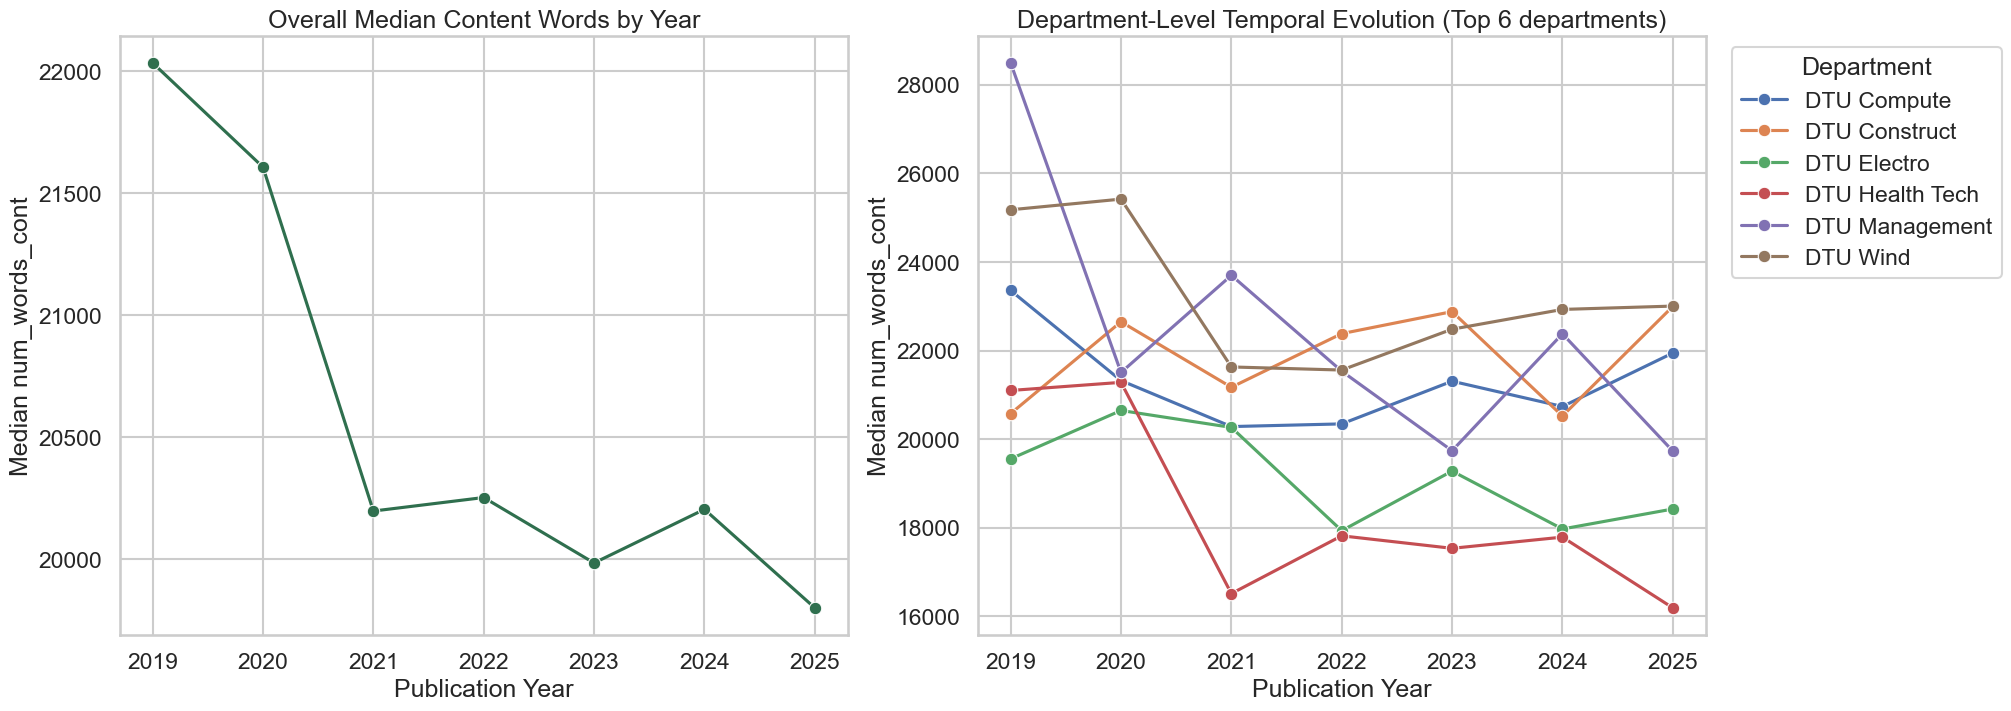

In [17]:
# 3B) Temporal evolution of thesis length
yearly_overall = (
    analysis_df.groupby("Publication Year", as_index=False)["num_words_cont"]
    .median()
    .sort_values("Publication Year")
)

top6_depts = analysis_df["Department_new"].value_counts().head(6).index
yearly_dept = (
    analysis_df[analysis_df["Department_new"].isin(top6_depts)]
    .groupby(["Publication Year", "Department_new"], as_index=False)["num_words_cont"]
    .median()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
sns.lineplot(data=yearly_overall, x="Publication Year", y="num_words_cont", marker="o", ax=axes[0], color="#2f6f4e")
axes[0].set_title("Overall Median Content Words by Year")
axes[0].set_ylabel("Median num_words_cont")

sns.lineplot(data=yearly_dept, x="Publication Year", y="num_words_cont", hue="Department_new", marker="o", ax=axes[1])
axes[1].set_title("Department-Level Temporal Evolution (Top 6 departments)")
axes[1].set_ylabel("Median num_words_cont")
axes[1].legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

### Narrative Insight: Temporal Evolution

If department trend lines diverge over time, writing-length norms are likely becoming more field-specific. Parallel movement across lines suggests institution-wide shifts (for example, formatting policy changes or broader pedagogical trends).

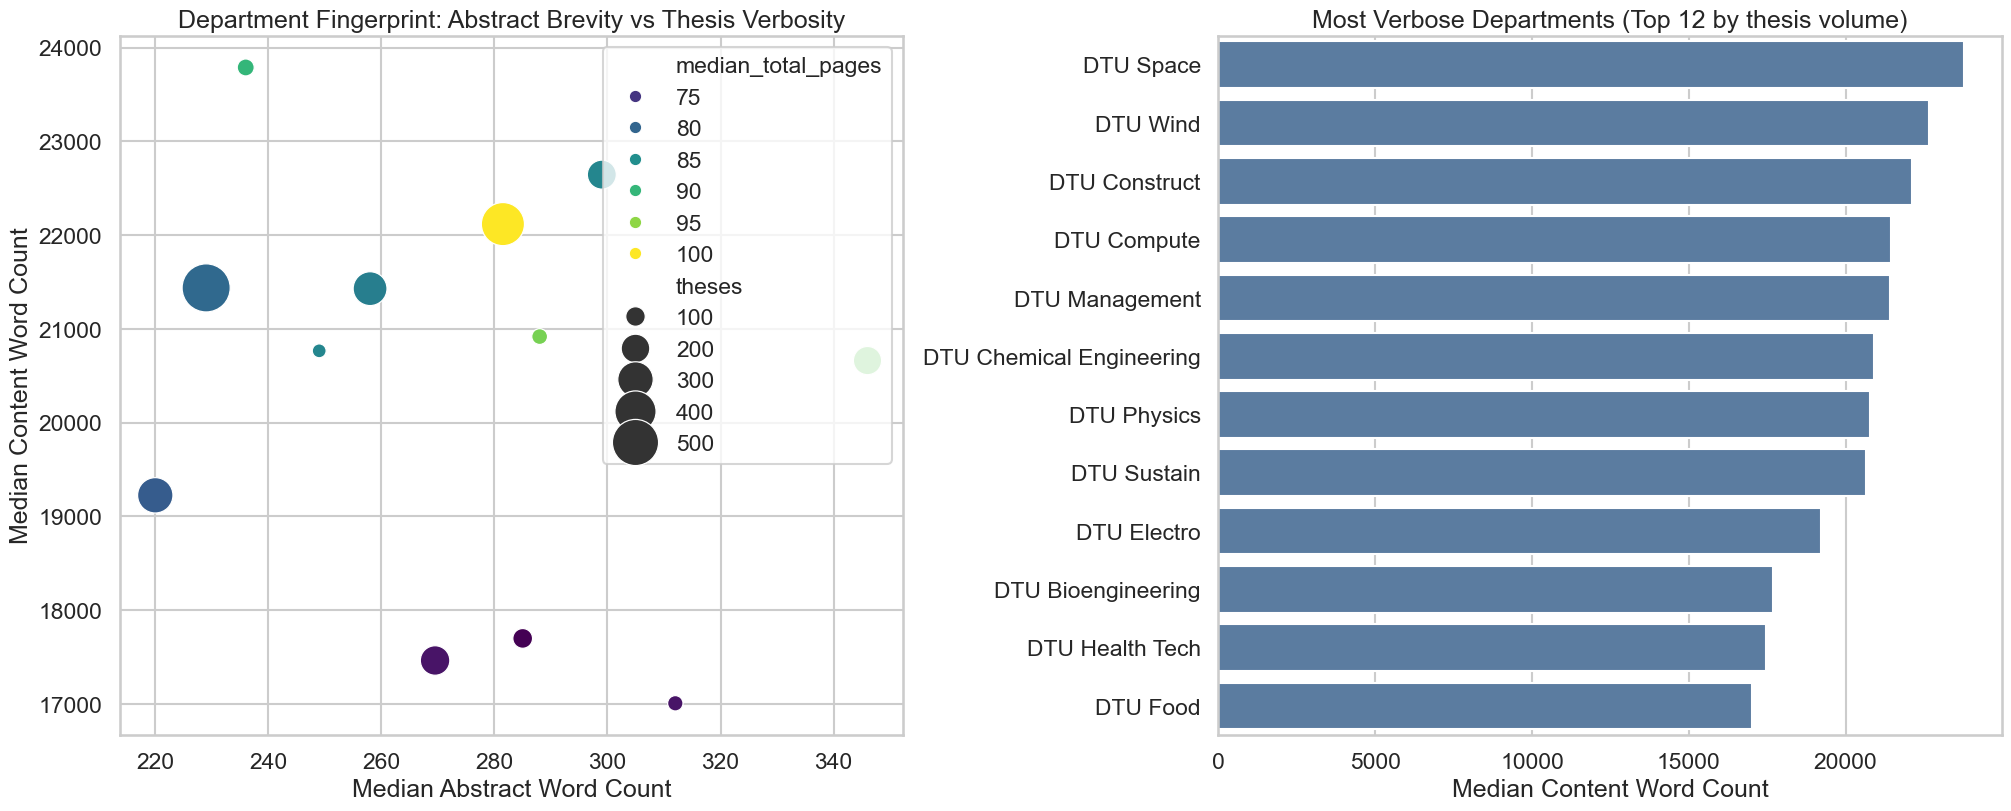

,Department_new,theses,median_content_words,median_total_pages,median_abstract_words
13,DTU Space,79,23788.0,90.0,236.0
15,DTU Wind,205,22645.0,84.0,299.0
5,DTU Construct,438,22117.5,100.0,281.5
4,DTU Compute,542,21437.0,80.5,229.0
11,DTU Management,275,21429.0,83.0,258.0
2,DTU Chemical Engineering,70,20918.0,94.0,288.0
12,DTU Physics,57,20766.0,84.0,249.0
14,DTU Sustain,195,20662.0,93.0,346.0
6,DTU Electro,299,19225.0,79.0,220.0
1,DTU Bioengineering,102,17699.0,70.5,285.0


In [18]:
# 3C) Departmental fingerprinting
fingerprint = (
    analysis_df.groupby("Department_new", as_index=False)
    .agg(
        theses=("member_id_ss_metrics", "count"),
        median_content_words=("num_words_cont", "median"),
        median_total_pages=("num_tot_pages", "median"),
        median_abstract_words=("abstract_word_count", "median"),
    )
    .sort_values("theses", ascending=False)
)

fp_top = fingerprint.head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
sns.scatterplot(
    data=fp_top,
    x="median_abstract_words",
    y="median_content_words",
    size="theses",
    hue="median_total_pages",
    palette="viridis",
    sizes=(100, 1200),
    ax=axes[0]
)
axes[0].set_title("Department Fingerprint: Abstract Brevity vs Thesis Verbosity")
axes[0].set_xlabel("Median Abstract Word Count")
axes[0].set_ylabel("Median Content Word Count")

verbose_rank = fp_top.sort_values("median_content_words", ascending=False)
sns.barplot(data=verbose_rank, x="median_content_words", y="Department_new", ax=axes[1], color="#4f7cac")
axes[1].set_title("Most Verbose Departments (Top 12 by thesis volume)")
axes[1].set_xlabel("Median Content Word Count")
axes[1].set_ylabel("")

plt.show()
display(fp_top.sort_values("median_content_words", ascending=False).head(12))

### Narrative Insight: Departmental Fingerprints

Departments with high content-word medians but short abstracts may prioritize technical depth over broad framing, while departments with longer abstracts may emphasize contextualization and research positioning. The fingerprint view highlights these disciplinary writing signatures.

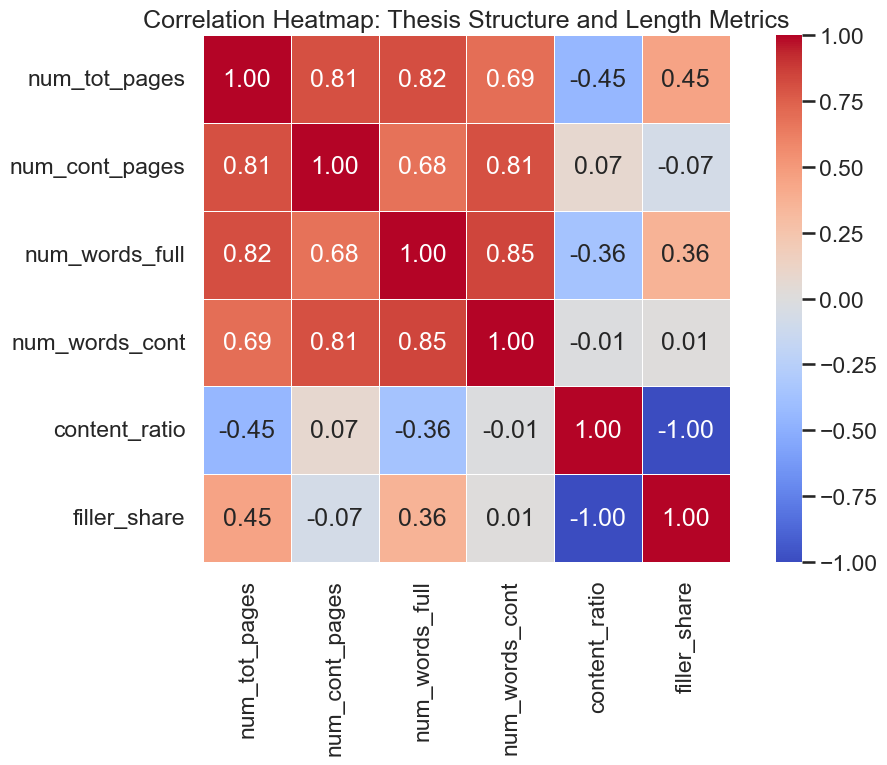

,num_tot_pages,num_cont_pages,num_words_full,num_words_cont,content_ratio,filler_share
num_tot_pages,1.00,0.81,0.82,0.69,-0.45,0.45
num_cont_pages,0.81,1.00,0.68,0.81,0.07,-0.07
num_words_full,0.82,0.68,1.00,0.85,-0.36,0.36
num_words_cont,0.69,0.81,0.85,1.00,-0.01,0.01
content_ratio,-0.45,0.07,-0.36,-0.01,1.00,-1.00
filler_share,0.45,-0.07,0.36,0.01,-1.00,1.00


In [19]:
# 3D) Correlation heatmap across structural and textual metrics
corr_cols = ["num_tot_pages", "num_cont_pages", "num_words_full", "num_words_cont", "abstract_word_count", "content_ratio", "filler_share"]
corr_df = analysis_df[corr_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Thesis Structure and Length Metrics")
plt.tight_layout()
plt.show()

display(corr.round(2))

### Narrative Insight: Correlation Structure

Strong positive correlations between page and word metrics are expected. More interesting are weak links between abstract length and full thesis length, which may indicate that abstract style is governed more by disciplinary norms than by document size.

In [20]:
# 4) Anomaly detection: extreme theses by content words and filler share
high_words_cutoff = analysis_df["num_words_cont"].quantile(0.99)
high_filler_cutoff = analysis_df["filler_share"].quantile(0.99)

anomalies = analysis_df[
    (analysis_df["num_words_cont"] >= high_words_cutoff) |
    (analysis_df["filler_share"] >= high_filler_cutoff)
][[
    "Title", "Author", "Department_new", "Publication Year",
    "num_words_cont", "num_tot_pages", "num_cont_pages", "filler_share"
]].sort_values(["num_words_cont", "filler_share"], ascending=False)

print(f"Anomalies found: {len(anomalies)}")
display(anomalies.head(20))

Anomalies found: 54


,Title,Author,Department_new,Publication Year,num_words_cont,num_tot_pages,num_cont_pages,filler_share
1302,Studying mixing processes in stars using TESS ...,"Pedros, Oliver Dürfeldt",DTU Space,2023,147132,436,436,0.000000
1667,Foundations without concrete in Danish buildin...,"Grunnan, Mads Dalsgaard",DTU Construct,2024,110324,531,426,0.197740
1559,Investigation of settlement of masts of a powe...,"Ville, Tom De",DTU Sustain,2023,88215,253,222,0.122530
362,The Development and Use of Backcasting as Meth...,"Kade, Oliver Howard|Lenz, Matthias",DTU Sustain,2020,76304,194,159,0.180412
1488,"Slope stability assessment of Longyeardalen, S...","Ciorescu, Marian Bogdan",DTU Chemistry,2023,71108,213,169,0.206573
334,Establishing an understanding of organisations...,"Pedersen, Tobias Oppenhagen",DTU Construct,2020,70393,280,280,0.000000
291,Ultra-violet supercontinuum generation in gas-...,"Moltke, Asbjørn Meldgaard",DTU Electro,2020,68802,206,206,0.000000
997,Sizing and Performance Assessment of Battery E...,"Thomassen, Steffen Grundahl|Pedersen, Jonas",DTU Electro,2022,65126,214,151,0.294393
2429,Machine Unlearning for Deep Neural Networks|Ma...,"Fiehn, Andreas Lyhne|Tollerup, August Brogaard...",DTU Compute,2025,63581,170,124,0.270588
1606,Structural load analysis and optimization of t...,"Senden, Nienke",DTU Wind,2023,62459,141,125,0.113475


## 5) Final Narrative Synthesis

This dataset reveals that thesis writing is not a single institutional style but a constellation of disciplinary conventions.

Key takeaways:
- **Structure varies by department**: filler share distributions suggest different expectations for appendices and references.
- **Length evolves over time**: median trends indicate whether thesis bodies are expanding or stabilizing.
- **Departmental fingerprints are distinct**: abstract behavior and body verbosity do not always move together.
- **Correlations reveal design logic**: pages and words scale together, while abstract length can remain comparatively independent.

For publication, these plots can be exported as high-resolution figures and accompanied by department-level significance testing (for example, Kruskal-Wallis across departments).